In [6]:
from function_lib import *

In [7]:

class DIOECPParam:
    """
    Implements the DIO exponential-cone program:

        minimize   (1/N) * sum_n t_n

        s.t.       ( (B^T x_n)^T (z*(c_n) - z_k) - t_n,  η,  v_{n,k} ) ∈ K_exp
                   sum_k v_{n,k} ≤ η

        where z*(c_n) is passed as a PARAMETER (computed from C and Z).
    """

    # ----------------------------------------------------------------------
    def __init__(self, N, d_x, d_c, Z, eta: float):
        self.N = int(N)
        self.d_x = int(d_x)
        self.d_c = int(d_c)

        self.Z = np.asarray(Z, float)          # (K, d_c)
        self.K = self.Z.shape[0]
        self.eta = float(eta)

        self._build_model()

    # ----------------------------------------------------------------------
    def _build_model(self):
        M = Model("dio_ecp_param")
        self.M = M

        # --------------------------
        # Parameters
        # --------------------------
        self.Xpar = M.parameter("X", [self.N, self.d_x])          # (N, d_x)
        self.Zstar_par = M.parameter("Zstar", [self.N, self.d_c]) # (N, d_c)

        # --------------------------
        # Variables
        # --------------------------
        self.B = M.variable("B", [self.d_x, self.d_c], Domain.unbounded())
        self.t = M.variable("t", self.N, Domain.unbounded())          # t_n ∈ R
        self.v = M.variable("v", [self.N, self.K], Domain.unbounded())  # v_{n,k}

        # --------------------------
        # Expressions
        # --------------------------
        # XB = X B → (N,d_c)
        XB = Expr.mul(self.Xpar, self.B)   # (N, d_c) — predicted cost vectors

        # Φ = XB Z^T → (N,K), each entry is (B^T x_n)^T z_k
        Zmat = Matrix.dense(self.Z.T)      # (d_c, K)
        Phi = Expr.mul(XB, Zmat)           # (N, K)

        # s_n = (B^T x_n)^T z*(c_n)
        prod = Expr.mulElm(XB, self.Zstar_par)   # (N,d_c)
        s = Expr.sum(prod, 1)                     # (N,)

        # u_{n,k} = (B^T x_n)^T (z*(c_n) - z_k) = s_n - Φ_{n,k}
        s_expanded = Expr.repeat(s, self.K, 1)    # (N,K)
        u = Expr.sub(s_expanded, Phi)             # (N,K)

        # x0_{n,k} = u_{n,k} - t_n
        t_expanded = Expr.repeat(self.t, self.K, 1)   # (N,K)
        x0 = Expr.sub(u, t_expanded)                  # (N,K)

        # Vectorize for the cone: (x0_vec, eta_vec, v_vec) ∈ K_exp
        x0_vec = Expr.reshape(x0, self.N * self.K, 1)         # (NK,1)
        v_vec = Expr.reshape(self.v, self.N * self.K, 1)      # (NK,1)

        eta_vec = Matrix.dense(np.full((self.N * self.K, 1), self.eta))
        eta_expr = Expr.constTerm(eta_vec)

        # Exponential cone: (x0, x1, x2) = (u - t, eta, v)
        triple = Expr.hstack(v_vec, eta_expr, x0_vec)
        M.constraint("exp_cone", triple, Domain.inPExpCone())

        # sum_k v_{n,k} ≤ η
        M.constraint(
            "sum_v",
            Expr.sum(self.v, 1),
            Domain.lessThan(np.full(self.N, self.eta))
        )

        # --------------------------
        # Objective: (1/N) * sum_n t_n
        # --------------------------
        obj = Expr.mul(1.0 / self.N, Expr.sum(self.t))
        M.objective("dio_obj", ObjectiveSense.Minimize, obj)

    # ----------------------------------------------------------------------
    # Compute oracle Zstar(c)
    # ----------------------------------------------------------------------
    def _compute_Zstar_from_C(self, C):
        """
        Compute z*(c_n) = argmin_z c_n^T z
        Return shape (N, d_c).
        """
        C = np.asarray(C, float)            # (N, d_c)
        costs = C @ self.Z.T               # (N, K)
        idx = costs.argmin(axis=1)         # (N,)
        Zstar = self.Z[idx]                # (N, d_c)
        return Zstar

    # ----------------------------------------------------------------------
    # Solve model
    # ----------------------------------------------------------------------
    def solve(self, X, C, verbose=False):
        X = np.asarray(X, float)
        C = np.asarray(C, float)

        # Set parameters
        self.Xpar.setValue(X)
        self.Zstar_par.setValue(self._compute_Zstar_from_C(C))

        if not verbose:
            self.M.setLogHandler(None)

        self.M.solve()

        B_val = np.array(self.B.level()).reshape(self.d_x, self.d_c)
        t_val = np.array(self.t.level())
        v_val = np.array(self.v.level()).reshape(self.N, self.K)
        obj_val = self.M.primalObjValue()

        return {
            "B": B_val,
            "t": t_val,
            "v": v_val,
            "obj": obj_val,
        }

    # ----------------------------------------------------------------------
    # REGRET EVALUATION (unchanged)
    # ----------------------------------------------------------------------
    def evaluate_regret(self, X_test, C_test, B=None, return_per_sample=False):
        """
        regret = c^T z_pred - c^T z*
        """
        X_test = np.asarray(X_test, float)
        C_test = np.asarray(C_test, float)

        N_test = X_test.shape[0]

        # Load B
        if B is None:
            B = np.array(self.B.level()).reshape(self.d_x, self.d_c)
        else:
            B = np.asarray(B, float).reshape(self.d_x, self.d_c)

        # Predicted cost vectors
        C_hat = X_test @ B                        # (N,d)

        # Evaluate predicted objective over all feasible z
        pred_costs = C_hat @ self.Z.T             # (N,K)
        idx_pred = np.argmin(pred_costs, axis=1)  # predicted z

        # True evaluation
        true_costs = C_test @ self.Z.T            # (N,K)
        oracle_costs = true_costs.min(axis=1)
        chosen_true_costs = true_costs[np.arange(N_test), idx_pred]

        regrets = chosen_true_costs - oracle_costs
        avg_regret = float(regrets.mean())

        result = {"avg_regret": avg_regret}
        if return_per_sample:
            result["regret_per_sample"] = regrets

        return result


In [8]:
# ----------------- config -----------------
n_instance   = 100
input_dim    = 3
noise        = 0.5
deg          = 2
grid_width   = 3
n_simulation = 30

# ----------------- paths ------------------
base_path = change_to_py_file_dir()
base      = os.path.join(base_path, "Data", "Shortest_path")

# ----------------- results ----------------
total_result  = {}
# =========================================================
# main loop over seeds
# =========================================================

# ----- build Z (all feasible z) only once -----
sols, edges, G = generate_all_feasible_solutions(grid_width=grid_width)
model_list = ["DIO-0.1", "DIO-1", "DIO-10", "DIO-100", "DIO-1000", "DIO-10000", "DIO-100000", "DIO-1000000"]

for model_type in model_list:
    regret_result = []
    parame_result = []

    if "DIO-" in model_type:
        eta = float(model_type.split("-")[1])
    else:
        raise ValueError(f"Unknown model type: {model_type}")
    print(eta)
    
    solver = None  # will build once on the first iteration

    for seed in tqdm(range(n_simulation),
                     desc="Running simulations",
                     colour="green"):

        # ---- reproducibility ----
        random.seed(seed)
        np.random.seed(seed)

        # ---- data for this seed ----
        x_train, y_train, x_test, y_test = load_shortest_path_setting_with_splits(
            base, n_instance, input_dim, deg, noise, grid_width, seed
        )
        
        # ---- build solver only once (reuse the same model) ----
        if solver is None:
            solver = DIOECPParam(
                N=x_train.shape[0],       # must be constant across seeds
                d_x=x_train.shape[1],
                d_c=y_train.shape[1],
                Z=sols,                   # Z is fixed set of feasible decisions
                eta=eta
            )

        # ---- solve training problem for this seed ----
        res = solver.solve(x_train, y_train, verbose=False)

        # ---- evaluate regret on test set ----
        # B is already stored in solver.B after solve(), so B argument is optional
        eval_res = solver.evaluate_regret(
            x_test, y_test, return_per_sample=False
        )

        regret_result.append(eval_res["avg_regret"])
        parame_result.append(res["B"])

    # save results for this model type
    total_result[model_type] = {
        "regret": regret_result,
        "params": parame_result
    }
    # ==================================================
    # CRITICAL FIX: Clean up memory before next model!
    # ==================================================
    if solver is not None:
        solver.M.dispose()  # Release Mosek C-memory immediately
        del solver          # Delete Python object
    
    gc.collect()            # Force Python Garbage Collector

    process = psutil.Process(os.getpid())
    print(f"Python process RAM: {process.memory_info().rss/1024/1024/1024:.3f} GB")

# Save the result to pickle file
save_path = os.path.join(base_path, "Results", "Score")
os.makedirs(save_path, exist_ok=True)   # create directory if not exist
file_path = os.path.join(save_path, f"Shortest_path_DIO_a_result_{n_instance}_{input_dim}_{deg}_{noise}_{grid_width}.pkl")
with open(file_path, "wb") as f:
    pickle.dump(total_result, f)

def print_memory():
    mem = psutil.virtual_memory()
    print(f"Available: {mem.available/1024/1024/1024:.2f} GB")
    print(f"Used:      {(mem.total - mem.available)/1024/1024/1024:.2f} GB")
    print(f"Percent:   {mem.percent}%")

print_memory()

0.1


Running simulations: 100%|██████████| 30/30 [00:00<00:00, 52.18it/s]


Python process RAM: 0.204 GB
1.0


Running simulations: 100%|██████████| 30/30 [00:00<00:00, 45.36it/s]


Python process RAM: 0.201 GB
10.0


...

Python process RAM: 0.203 GB
100000.0


Running simulations: 100%|██████████| 30/30 [00:00<00:00, 44.44it/s]


Python process RAM: 0.204 GB
1000000.0


Running simulations: 100%|██████████| 30/30 [00:00<00:00, 44.11it/s]

Python process RAM: 0.204 GB
Available: 54.26 GB
Used:      9.46 GB
Percent:   14.9%


C:\Users\zhaoz\AppData\Local\Temp\ipykernel_28036\4104540199.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


      Model     Mean      Std    VaR90   CVaR90
    DIO-0.1 3.525978 1.975942 6.746439 7.317374
      DIO-1 3.525978 1.975942 6.746439 7.317374
     DIO-10 3.525978 1.975942 6.746439 7.317374
    DIO-100 3.525978 1.975942 6.746439 7.317374
   DIO-1000 3.525978 1.975942 6.746439 7.317374
  DIO-10000 3.525978 1.975942 6.746439 7.317374
 DIO-100000 3.525978 1.975942 6.746439 7.317374
DIO-1000000 3.525978 1.975942 6.746439 7.317374


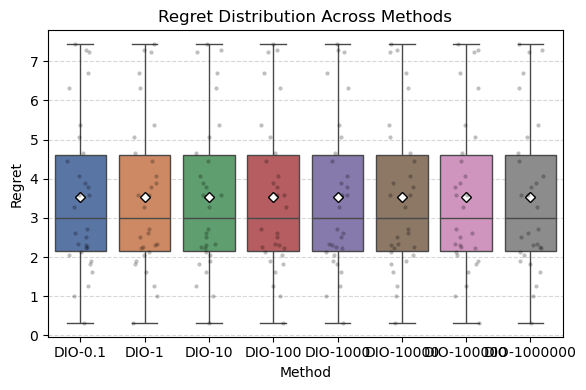

In [9]:
# Compute stats for the LST model
# regrets = total_result["LST-0.1"]["regret"]

# mean, std, var90, cvar90 = compute_stats(regrets)

# print(f"Mean    : {mean:.6f}")
# print(f"Std     : {std:.6f}")
# print(f"VaR 90  : {var90:.6f}")
# print(f"CVaR 90 : {cvar90:.6f}")
rows = []
for model_type in model_list:
    regrets = total_result[model_type]["regret"]
    mean, std, var90, cvar90 = compute_stats(regrets)

    rows.append({
        "Model": model_type,
        "Mean": mean,
        "Std": std,
        "VaR90": var90,
        "CVaR90": cvar90
    })

# convert to DataFrame
df = pd.DataFrame(rows)

# nicely formatted print
print(df.to_string(index=False, float_format="%.6f"))


# Collect regret distributions across all model types
df_list = []
for model_type, data in total_result.items():
    df_list.append(pd.DataFrame({
        "method": [model_type] * len(data["regret"]),
        "regret": data["regret"]
    }))

df = pd.concat(df_list, ignore_index=True)

# Academic color palette
palette = sns.color_palette("deep")
unique_methods = sorted(df["method"].unique())
method_colors = {m: palette[i % len(palette)] for i, m in enumerate(unique_methods)}

plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df,
    x="method",
    y="regret",
    palette=method_colors,
    showmeans=True,
    meanprops={
        "marker": "D",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 5
    }
)

sns.stripplot(
    data=df,
    x="method",
    y="regret",
    color="black",
    alpha=0.25,
    jitter=0.2,
    size=3
)

plt.title("Regret Distribution Across Methods", fontsize=12)
plt.ylabel("Regret")
plt.xlabel("Method")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

# Save figure
save_dir = os.path.join(base_path, "Results", "Figures")
os.makedirs(save_dir, exist_ok=True)

plt.savefig(
    os.path.join(save_dir, "regret_comparison.png"),
    dpi=400,
    bbox_inches="tight"
)

plt.show()

In [10]:
# seed = 1
# x_train, y_train, x_test, y_test = load_shortest_path_setting_with_splits(base, n_instance, input_dim, deg, noise, grid_width, seed)

# # Example usage:

# sols, edges, G = generate_all_feasible_solutions(grid_width=5)
# print("Number of edges:", len(edges))
# print("Number of feasible s->t paths:", len(sols))
# print("First solution vector:", sols[0])

# # pick any solution
# vec = sols[10]
# # draw
# draw_solution(G, edges, vec, grid_width=5, cost=y_train[0])
# solver = LSTECPParam(
#     N=x_train.shape[0],
#     d_x=x_train.shape[1],
#     d_c=y_train.shape[1],
#     Z=sols,
#     eta=0.5
# )

# X_run = x_train   # shape (N, d_x)
# C_run = y_train   # shape (N, d_c)

# res = solver.solve(X_run, C_run, verbose=False)
# eval_res = solver.evaluate_regret(x_test, y_test, return_per_sample=True)
# print("Avg regret:", eval_res["avg_regret"])
# # print("Per-sample regret:", eval_res["regret_per_sample"])
